# SEVIR (Storm EVent ImageRy) 데이터셋 EDA
## 딥러닝 기상 이벤트 예측 모델 학습을 위한 탐색적 데이터 분석

---

### 데이터셋 개요

**SEVIR**은 2018~2019년 미국 대륙의 폭풍 이벤트를 5개 센서로 동시 관측한 멀티모달 기상 이미지 데이터셋입니다.  
각 이벤트는 **4시간 시퀀스(5분 간격 × 49 프레임, 384×384 픽셀)** 로 구성됩니다.

| 채널 | 설명 | 해상도 | 형식 | 범위 |
|------|------|--------|------|------|
| `vil` | 수직 통합 액체 (NEXRAD 레이더) | 1 km | uint8 | 0–255 (→ 0–70 mm) |
| `vis` | 가시광선 위성 (GOES-16) | 0.5 km | uint8 | 0–255 |
| `ir069` | 수증기 채널 6.9 µm | 2 km | int16 | 단위: 0.01 K |
| `ir107` | 열적외선 채널 10.7 µm | 2 km | int16 | 단위: 0.01 K |
| `lght` | 번개 낙뢰 횟수 (Vaisala GLD360) | 48×48 그리드 | int16 | 5분 구간 낙뢰 수 |

### 분석 구조

| 단계 | 내용 |
|------|------|
| Step 1 | 패키지 설치 및 S3 연결 |
| Step 2 | CATALOG.csv 메타데이터 분석 |
| Step 3 | S3 HDF5 파일 구조 탐색 |
| Step 4 | 채널별 통계 및 분포 |
| Step 5 | 단일 이벤트 시각화 |
| Step 6 | 시계열 시퀀스 시각화 |
| Step 7 | 공간 평균·분산 맵 |
| Step 8 | 시간·계절 패턴 분석 |
| Step 9 | 채널 간 상관 분석 |
| Step 10 | 데이터 품질 점검 및 DL 학습 노트 |

---
## Step 1. 패키지 설치 및 환경 설정

- `s3fs` : S3 파일시스템 인터페이스 (익명 접근)
- `h5py` : HDF5 파일을 파이썬 file-like 객체 위에서 직접 읽기
- 로컬 다운로드 없이 **메모리 스트리밍**으로 데이터 접근

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/weather-climate-ai-tutorials

In [ ]:
# 나눔 고딕 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv

In [2]:
# 최초 실행 시 설치
# !pip install -q s3fs h5py pandas numpy matplotlib seaborn cartopy tqdm

# ── 한글 폰트 설치 및 등록 ────────────────────────────────────────────
import urllib.request, pathlib, matplotlib, matplotlib.font_manager as fm
import matplotlib.pyplot as plt

FONT_URLS = [
    "https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf",
    "https://raw.githubusercontent.com/googlefonts/noto-cjk/main/Sans/Variable/TTF/Subset/NotoSansCJKkr-VF.ttf",
]

font_dir  = pathlib.Path(matplotlib.get_data_path()) / "fonts" / "ttf"
font_path = font_dir / "NanumGothic.ttf"

if not font_path.exists():
    downloaded = False
    for url in FONT_URLS:
        try:
            print(f"다운로드 중: {url.split('/')[-1]} ...", end=" ")
            urllib.request.urlretrieve(url, font_path)
            print("완료")
            downloaded = True
            break
        except Exception as e:
            print(f"실패 ({e})")
    if not downloaded:
        print("모든 URL 실패 → 터미널에서 실행: conda install -c conda-forge font-ttf-nanum")

# ── 폰트 파일 경로로 직접 등록 ────────────────────────────────────────
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    _font_name = fm.FontProperties(fname=str(font_path)).get_name()
    plt.rcParams['font.family'] = _font_name
    plt.rcParams['axes.unicode_minus'] = False
    print(f"한글 폰트 등록 완료: '{_font_name}'")

한글 폰트 등록 완료: 'NanumGothic'


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
import h5py
import s3fs
import warnings
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# sns.set_style() 이 rcParams를 초기화하므로 반드시 이후에 폰트 재적용
sns.set_style('whitegrid')

import pathlib, matplotlib, matplotlib.font_manager as fm
font_path = pathlib.Path(matplotlib.get_data_path()) / "fonts" / "ttf" / "NanumGothic.ttf"
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    _font_name = fm.FontProperties(fname=str(font_path)).get_name()
    plt.rcParams['font.family'] = _font_name

plt.rcParams['axes.unicode_minus'] = False

print(f"numpy  : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"h5py   : {h5py.__version__}")
print(f"s3fs   : {s3fs.__version__}")
print(f"현재 폰트: {plt.rcParams['font.family']}")

numpy  : 2.2.6
pandas : 2.3.3
h5py   : 3.15.1
s3fs   : 2026.2.0
현재 폰트: ['NanumGothic']


In [4]:
# ── 데이터셋 상수 정의 ──────────────────────────────────────────────────
S3_ROOT   = 's3://sevir'
CATALOG_S3 = f'{S3_ROOT}/CATALOG.csv'

# 채널별 메타 정보
IMG_TYPES = {
    'vil'  : {'dtype': np.uint8,  'shape': (384, 384), 'n_frames': 49, 'unit': 'mm',  'vmin': 0,   'vmax': 70,   'cmap': 'Blues',      'description': '수직 통합 액체 (레이더)'},
    'vis'  : {'dtype': np.uint8,  'shape': (384, 384), 'n_frames': 49, 'unit': '–',  'vmin': 0,   'vmax': 255,  'cmap': 'gray',       'description': '가시광선 위성'},
    'ir069': {'dtype': np.int16,  'shape': (384, 384), 'n_frames': 49, 'unit': 'K',  'vmin': 180, 'vmax': 310,  'cmap': 'RdYlBu_r',  'description': '수증기 채널 6.9 µm'},
    'ir107': {'dtype': np.int16,  'shape': (384, 384), 'n_frames': 49, 'unit': 'K',  'vmin': 180, 'vmax': 310,  'cmap': 'RdYlBu_r',  'description': '열적외선 채널 10.7 µm'},
    'lght' : {'dtype': np.int16,  'shape': (48,  48),  'n_frames': 49, 'unit': '회', 'vmin': 0,   'vmax': 20,   'cmap': 'hot',        'description': '번개 낙뢰 횟수'},
}

# VIL 비선형 스케일 변환 LUT (0~255 → mm, SEVIR 논문 기준)
def make_vil_lut():
    r = np.zeros(256, dtype=np.float32)
    r[0]  = 0.0
    # 1–4: 0.08 mm 단계
    for i in range(1, 5):
        r[i] = 0.08 * i
    # 5–18: 구간별 비선형
    bounds = [(5,  18, 0.4),  (18, 57, 0.5),  (57, 111, 1.0),
              (111, 151, 2.0), (151, 191, 4.0), (191, 255, 8.0)]
    for lo, hi, step in bounds:
        for i in range(lo, min(hi, 256)):
            r[i] = r[lo - 1] + step * (i - lo + 1)
    return r

VIL_LUT = make_vil_lut()  # shape (256,)

def vil_to_mm(raw):           # uint8 → mm
    return VIL_LUT[raw.astype(int)]

def ir_to_kelvin(raw):        # int16 (×0.01 K) → K
    return raw.astype(np.float32) * 0.01

print("상수 정의 완료")
print(f"채널 목록: {list(IMG_TYPES.keys())}")

상수 정의 완료
채널 목록: ['vil', 'vis', 'ir069', 'ir107', 'lght']


In [5]:
# ── S3 익명 연결 ────────────────────────────────────────────────────────
fs = s3fs.S3FileSystem(anon=True)

# S3 루트 디렉토리 확인
root_contents = fs.ls(S3_ROOT)
print("S3 루트 디렉토리 구조:")
for item in sorted(root_contents):
    print(f"  {item}")

S3 루트 디렉토리 구조:
  sevir/CATALOG.csv
  sevir/data


---
## Step 2. CATALOG.csv 메타데이터 분석

`CATALOG.csv`는 각 이벤트의 파일 경로, 시공간 메타데이터를 담고 있습니다.  
S3에서 직접 `pandas`로 스트리밍 로드합니다.

In [6]:
# ── CATALOG.csv S3 스트리밍 로드 ─────────────────────────────────────
print(f"로드 중: {CATALOG_S3}")
catalog = pd.read_csv(
    CATALOG_S3,
    storage_options={'anon': True},
    parse_dates=['time_utc'],
    low_memory=False,
)

print(f"\n카탈로그 형태: {catalog.shape}  (행=이벤트×채널, 열=메타데이터)")
print(f"컬럼 목록:\n{list(catalog.columns)}")
catalog.head()

로드 중: s3://sevir/CATALOG.csv

카탈로그 형태: (76004, 21)  (행=이벤트×채널, 열=메타데이터)
컬럼 목록:
['id', 'file_name', 'file_index', 'img_type', 'time_utc', 'minute_offsets', 'episode_id', 'event_id', 'event_type', 'llcrnrlat', 'llcrnrlon', 'urcrnrlat', 'urcrnrlon', 'proj', 'size_x', 'size_y', 'height_m', 'width_m', 'data_min', 'data_max', 'pct_missing']


,id,file_name,file_index,img_type,time_utc,minute_offsets,episode_id,event_id,event_type,llcrnrlat,...,urcrnrlat,urcrnrlon,proj,size_x,size_y,height_m,width_m,data_min,data_max,pct_missing
0,R18032505027684,vis/2018/SEVIR_VIS_RANDOMEVENTS_2018_0321_0331.h5,0,vis,2018-03-25 05:00:00,-120:-115:-110:-105:-100:-95:-90:-85:-80:-75:-...,NaN,NaN,NaN,33.216708,...,36.336627,-87.070254,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,768,768,384000.0,384000.0,-0.003361,0.005600,0.0
1,R18032505027677,vis/2018/SEVIR_VIS_RANDOMEVENTS_2018_0321_0331.h5,1,vis,2018-03-25 05:00:00,-120:-115:-110:-105:-100:-95:-90:-85:-80:-75:-...,NaN,NaN,NaN,33.084309,...,36.213723,-87.301535,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,768,768,384000.0,384000.0,-0.003361,0.005600,0.0
2,R18032505027721,vis/2018/SEVIR_VIS_RANDOMEVENTS_2018_0321_0331.h5,2,vis,2018-03-25 05:00:00,-120:-115:-110:-105:-100:-95:-90:-85:-80:-75:-...,NaN,NaN,NaN,46.661866,...,50.883159,-120.009277,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,768,768,384000.0,384000.0,-0.002870,0.005548,0.0
3,R18032516508249,vis/2018/SEVIR_VIS_RANDOMEVENTS_2018_0321_0331.h5,3,vis,2018-03-25 16:50:00,-120:-115:-110:-105:-100:-95:-90:-85:-80:-75:-...,NaN,NaN,NaN,40.883237,...,43.686191,-79.903987,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,768,768,384000.0,384000.0,0.029911,0.785600,0.0
4,R18032516507621,vis/2018/SEVIR_VIS_RANDOMEVENTS_2018_0321_0331.h5,4,vis,2018-03-25 16:50:00,-120:-115:-110:-105:-100:-95:-90:-85:-80:-75:-...,NaN,NaN,NaN,44.946047,...,49.169436,-120.575175,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,768,768,384000.0,384000.0,0.028560,0.792610,0.0


In [7]:
# ── 기본 정보 ──────────────────────────────────────────────────────────
print("=" * 55)
print("데이터 타입 및 결측치")
print("=" * 55)
info_df = pd.DataFrame({
    'dtype'    : catalog.dtypes,
    'non_null' : catalog.notna().sum(),
    'null_rate' : (catalog.isna().mean() * 100).round(2),
})
print(info_df.to_string())

print("\n수치형 컬럼 요약:")
catalog.describe().T

데이터 타입 및 결측치
                         dtype  non_null  null_rate
id                      object     76004       0.00
file_name               object     76004       0.00
file_index               int64     76004       0.00
img_type                object     76004       0.00
time_utc        datetime64[ns]     76004       0.00
minute_offsets          object     60889      19.89
episode_id             float64     16644      78.10
event_id               float64     16644      78.10
event_type              object     16644      78.10
llcrnrlat              float64     76004       0.00
llcrnrlon              float64     76004       0.00
urcrnrlat              float64     76004       0.00
urcrnrlon              float64     76004       0.00
proj                    object     76004       0.00
size_x                   int64     76004       0.00
size_y                   int64     76004       0.00
height_m               float64     76004       0.00
width_m                float64     76004       0.00

,count,mean,min,25%,50%,75%,max,std
file_index,76004.0,560.197529,0.0,34.0,288.0,953.0,2367.0,623.882922
time_utc,76004,2018-12-16 13:35:57.828403968,2017-06-13 03:36:00,2018-07-16 23:39:00,2018-12-09 03:25:00,2019-06-19 01:30:00,2019-11-30 18:46:15,NaN
episode_id,16644.0,131898.503124,115450.0,126873.0,130722.0,137854.0,143171.0,6554.690915
event_id,16644.0,792305.565008,693411.0,761980.0,783119.0,829963.0,858968.0,39970.776555
llcrnrlat,76004.0,35.887213,22.037719,31.504089,35.903517,40.250779,47.645195,5.594123
llcrnrlon,76004.0,-95.095556,-127.236023,-101.958669,-93.610103,-85.501705,-69.596153,12.521709
urcrnrlat,76004.0,39.100375,24.884712,34.784482,39.161088,43.301538,51.896772,5.636998
urcrnrlon,76004.0,-90.501528,-124.092009,-97.60541,-88.8207,-80.64909,-62.923894,13.103339
size_x,76004.0,316.454292,48.0,192.0,192.0,384.0,768.0,238.818327
size_y,76004.0,316.454292,48.0,192.0,192.0,384.0,768.0,238.818327


채널별 이벤트 레코드 수:
img_type
vil      20393
lght     15115
ir069    13552
ir107    13541
vis      13403


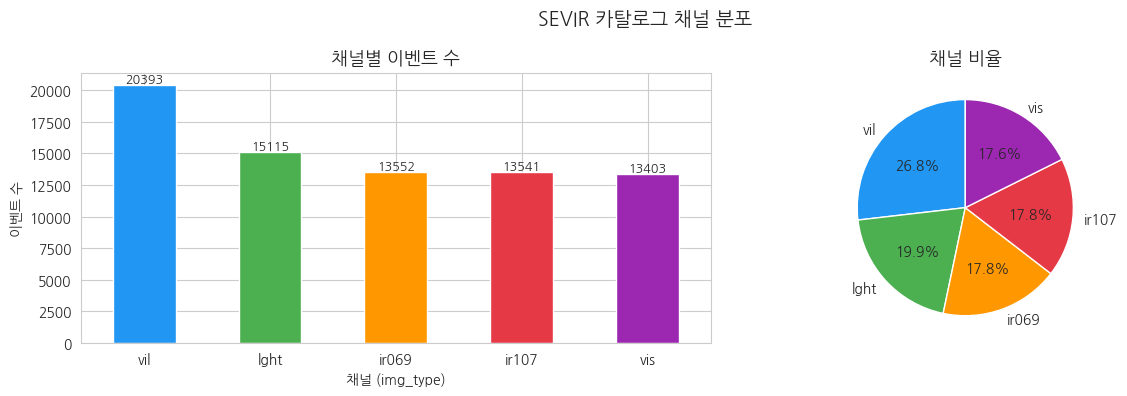

In [8]:
# ── 채널(img_type)별 이벤트 수 ────────────────────────────────────────
imgtype_counts = catalog['img_type'].value_counts()
print("채널별 이벤트 레코드 수:")
print(imgtype_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

imgtype_counts.plot(
    kind='bar', ax=axes[0],
    color=['#2196F3','#4CAF50','#FF9800','#E63946','#9C27B0'],
    edgecolor='white', rot=0
)
axes[0].set_title('채널별 이벤트 수', fontsize=13)
axes[0].set_xlabel('채널 (img_type)')
axes[0].set_ylabel('이벤트 수')
axes[0].bar_label(axes[0].containers[0], fontsize=9)

imgtype_counts.plot(
    kind='pie', ax=axes[1],
    colors=['#2196F3','#4CAF50','#FF9800','#E63946','#9C27B0'],
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10}
)
axes[1].set_title('채널 비율', fontsize=13)
axes[1].set_ylabel('')

plt.suptitle('SEVIR 카탈로그 채널 분포', fontsize=14)
plt.tight_layout()
plt.show()

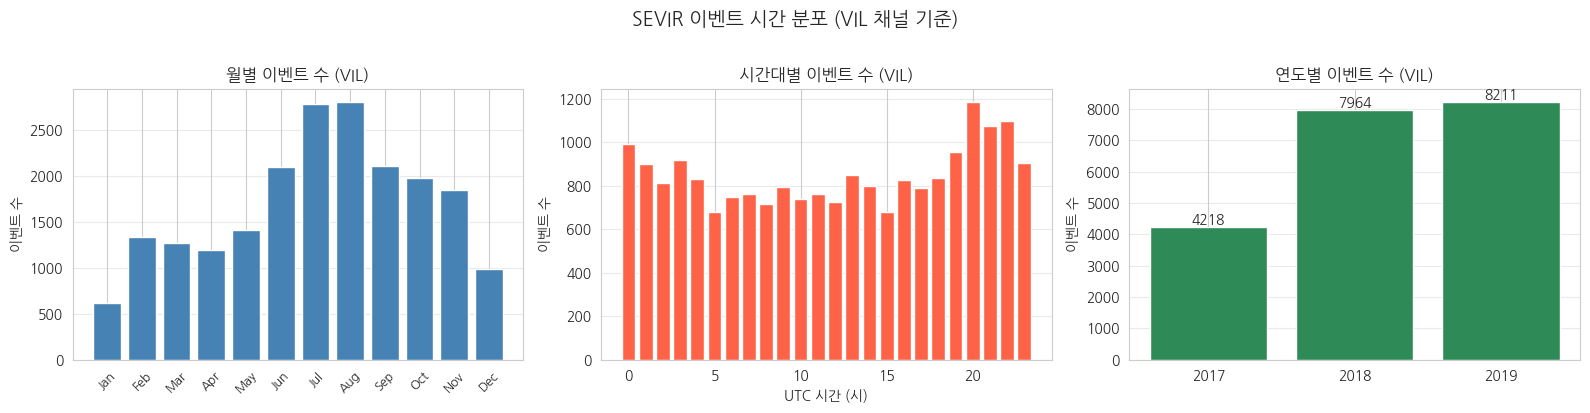

In [9]:
# ── 시간 분포 분석 ────────────────────────────────────────────────────
cat_vil = catalog[catalog['img_type'] == 'vil'].copy()
cat_vil['year']  = cat_vil['time_utc'].dt.year
cat_vil['month'] = cat_vil['time_utc'].dt.month
cat_vil['hour']  = cat_vil['time_utc'].dt.hour
cat_vil['dayofweek'] = cat_vil['time_utc'].dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# 월별
monthly = cat_vil.groupby('month').size()
axes[0].bar(monthly.index, monthly.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names, rotation=45, fontsize=9)
axes[0].set_title('월별 이벤트 수 (VIL)', fontsize=12)
axes[0].set_ylabel('이벤트 수')
axes[0].grid(axis='y', alpha=0.4)

# 시간대별
hourly = cat_vil.groupby('hour').size()
axes[1].bar(hourly.index, hourly.values, color='tomato', edgecolor='white')
axes[1].set_xlabel('UTC 시간 (시)')
axes[1].set_title('시간대별 이벤트 수 (VIL)', fontsize=12)
axes[1].set_ylabel('이벤트 수')
axes[1].grid(axis='y', alpha=0.4)

# 연도별
yearly = cat_vil.groupby('year').size()
axes[2].bar(yearly.index.astype(str), yearly.values, color='seagreen', edgecolor='white')
axes[2].set_title('연도별 이벤트 수 (VIL)', fontsize=12)
axes[2].set_ylabel('이벤트 수')
axes[2].bar_label(axes[2].containers[0], fontsize=10)
axes[2].grid(axis='y', alpha=0.4)

plt.suptitle('SEVIR 이벤트 시간 분포 (VIL 채널 기준)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

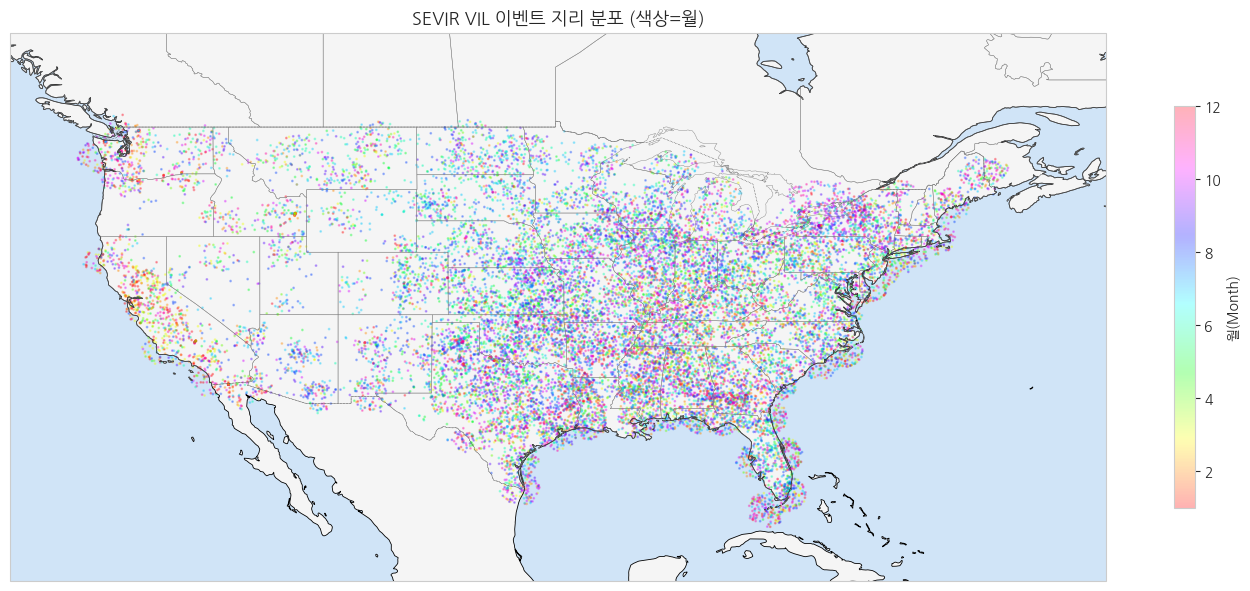

In [10]:
# ── 이벤트 지리 분포 산점도 ───────────────────────────────────────────
# 중심 위경도 계산
cat_vil['lat_center'] = (cat_vil['llcrnrlat'] + cat_vil['urcrnrlat']) / 2
cat_vil['lon_center'] = (cat_vil['llcrnrlon'] + cat_vil['urcrnrlon']) / 2

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig, ax = plt.subplots(figsize=(14, 7),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cfeature.LAND,      facecolor='#f5f5f5')
    ax.add_feature(cfeature.OCEAN,     facecolor='#d0e4f7')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=':')
    ax.add_feature(cfeature.STATES,    linewidth=0.3, edgecolor='gray')
    ax.set_extent([-130, -60, 20, 55], crs=ccrs.PlateCarree())

    sc = ax.scatter(
        cat_vil['lon_center'], cat_vil['lat_center'],
        c=cat_vil['month'], cmap='hsv',
        s=1, alpha=0.3, transform=ccrs.PlateCarree()
    )
    plt.colorbar(sc, ax=ax, label='월(Month)', shrink=0.6)
    ax.set_title('SEVIR VIL 이벤트 지리 분포 (색상=월)', fontsize=13)
    plt.tight_layout()
    plt.show()

except ImportError:
    # cartopy 없을 경우 간단한 산점도
    fig, ax = plt.subplots(figsize=(12, 6))
    sc = ax.scatter(
        cat_vil['lon_center'], cat_vil['lat_center'],
        c=cat_vil['month'], cmap='hsv', s=1, alpha=0.3
    )
    plt.colorbar(sc, ax=ax, label='월(Month)')
    ax.set_xlabel('경도 (°E)')
    ax.set_ylabel('위도 (°N)')
    ax.set_title('SEVIR VIL 이벤트 지리 분포 (색상=월)', fontsize=13)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## Step 2-A. 완전한 샘플 이벤트 검색 (2018년 필터링)

2018년 데이터 중 **5개 모달리티(vil, vis, ir069, ir107, lght)가 모두 존재**하는  
완전한(complete) 이벤트 하나를 카탈로그에서 탐색합니다.

카탈로그의 `file_name` / `file_index` 컬럼을 통해 각 채널의 HDF5 파일 경로와  
파일 내 이벤트 인덱스를 정확히 매핑합니다.

---
## Step 3. S3 HDF5 파일 구조 탐색

`s3fs` + `h5py`를 이용해 로컬 저장 없이 S3에서 직접 HDF5를 열어  
데이터 구조와 어트리뷰트를 확인합니다.

In [11]:
# ── S3 data 디렉토리 구조 확인 ────────────────────────────────────────
data_dir = f'{S3_ROOT}/data'
print("S3 data/ 디렉토리:")
for ch_dir in sorted(fs.ls(data_dir)):
    files = fs.ls(ch_dir)
    print(f"  {ch_dir}/  ({len(files)}개 파일)")
    for f in sorted(files)[:3]:   # 처음 3개만 출력
        size_mb = fs.info(f)['size'] / 1e6
        print(f"    {f.split('/')[-1]}  ({size_mb:.0f} MB)")
    if len(files) > 3:
        print(f"    ... 외 {len(files)-3}개")

S3 data/ 디렉토리:
  sevir/data//  (7개 파일)
      (0 MB)
    ir069  (0 MB)
    ir107  (0 MB)
    ... 외 4개
  sevir/data/ir069/  (2개 파일)
    2018  (0 MB)
    2019  (0 MB)
  sevir/data/ir107/  (2개 파일)
    2018  (0 MB)
    2019  (0 MB)
  sevir/data/lght/  (2개 파일)
    2018  (0 MB)
    2019  (0 MB)
  sevir/data/processed/  (4개 파일)
    nowcast_testing_000.h5.tar.gz  (5119 MB)
    nowcast_testing_000_META.csv  (1 MB)
    nowcast_training_000.h5.tar.gz  (14360 MB)
    ... 외 1개
  sevir/data/vil/  (3개 파일)
    2017  (0 MB)
    2018  (0 MB)
    2019  (0 MB)
  sevir/data/vis/  (2개 파일)
    2018  (0 MB)
    2019  (0 MB)


In [12]:
# ── S3 .h5 파일 탐색 (디렉토리 깊이 무관) ────────────────────────────
import io

def list_h5_files(channel):
    base    = f'{S3_ROOT}/data/{channel}'
    entries = fs.ls(base, detail=True)
    files   = []
    for e in entries:
        if e['type'] == 'file' and e['name'].endswith('.h5'):
            files.append(e['name'])
        elif e['type'] == 'directory':
            sub = fs.ls(e['name'], detail=True)
            files.extend(s['name'] for s in sub
                         if s['type'] == 'file' and s['name'].endswith('.h5'))
    return sorted(files)

class S3BufferedFile(io.RawIOBase):
    def __init__(self, s3_path):
        self._f = fs.open(s3_path, 'rb', cache_type='bytes',
                          block_size=8 * 1024 * 1024)
    def readable(self):  return True
    def seekable(self):  return True
    def readinto(self, b):
        data = self._f.read(len(b))
        n = len(data)
        if n: b[:n] = data
        return n
    def seek(self, pos, whence=0):  return self._f.seek(pos, whence)
    def tell(self):                 return self._f.tell()
    def close(self):
        self._f.close()
        super().close()

def open_h5_s3(s3_path):
    try:
        raw = S3BufferedFile(s3_path)
        buf = io.BufferedReader(raw, buffer_size=8 * 1024 * 1024)
        return h5py.File(buf, 'r')
    except Exception as e1:
        size_mb = fs.info(s3_path)['size'] / 1e6
        print(f"  스트리밍 실패({e1.__class__.__name__}), "
              f"BytesIO 폴백 ({size_mb:.0f} MB 다운로드 중)...")
        with fs.open(s3_path, 'rb') as raw:
            buf = io.BytesIO(raw.read())
        return h5py.File(buf, 'r')

def _resolve_key(hf, channel):
    """
    HDF5 파일 안에서 실제 데이터셋 키를 결정합니다.
    채널명과 일치하는 키가 없으면 파일 내 첫 번째 Dataset 키를 사용합니다.
    """
    if channel in hf:
        return channel
    # Dataset 키만 수집 (Group 제외)
    dataset_keys = [k for k in hf.keys() if isinstance(hf[k], h5py.Dataset)]
    if not dataset_keys:
        raise KeyError(f"HDF5 파일에 Dataset이 없습니다. 키 목록: {list(hf.keys())}")
    key = dataset_keys[0]
    print(f"  주의: '{channel}' 키 없음 → '{key}' 키로 대체 (파일 내 키: {list(hf.keys())})")
    return key

def load_events_from_s3(channel, indices, file_idx=0):
    """
    S3 HDF5에서 지정 인덱스의 이벤트만 슬라이싱해 반환합니다.

    Parameters
    ----------
    channel  : str       채널명 (vil, vis, ir069, ir107, lght)
    indices  : list[int] 가져올 이벤트 인덱스 목록
    file_idx : int       파일 번호 (기본 0)

    Returns
    -------
    data : np.ndarray  shape (len(indices), H, W, T)
    path : str         사용된 S3 경로
    """
    h5_files = list_h5_files(channel)
    s3_path  = h5_files[file_idx]
    print(f"  [{channel}] {s3_path.split('/')[-1]}")
    with open_h5_s3(s3_path) as hf:
        key  = _resolve_key(hf, channel)
        data = hf[key][indices]
    return data.copy(), s3_path

print("헬퍼 함수 정의 완료: list_h5_files / open_h5_s3 / load_events_from_s3")

헬퍼 함수 정의 완료: list_h5_files / open_h5_s3 / load_events_from_s3


In [13]:
# ── HDF5 파일 내부 구조 탐색 (VIL 첫 번째 파일 기준) ─────────────────
# list_h5_files()는 아래 cell-streaming-helper 셀에 정의되어 있습니다.
# 이 셀은 반드시 그 이후에 실행하세요.

def explore_hdf5_structure(s3_path):
    """HDF5 파일의 키, shape, dtype, attribute를 출력합니다."""
    print(f"파일: {s3_path.split('/')[-1]}")
    print(f"크기: {fs.info(s3_path)['size'] / 1e6:.0f} MB")
    print("-" * 60)
    with open_h5_s3(s3_path) as hf:
        def _print_tree(name, obj):
            indent = '  ' * name.count('/')
            if isinstance(obj, h5py.Dataset):
                print(f"{indent}[Dataset] /{name}")
                print(f"{indent}          shape={obj.shape}, dtype={obj.dtype}")
                if obj.attrs:
                    for k, v in obj.attrs.items():
                        print(f"{indent}          attr.{k} = {v}")
            elif isinstance(obj, h5py.Group):
                print(f"{indent}[Group]   /{name}/")
        hf.visititems(_print_tree)

vil_h5_files = list_h5_files('vil')
print(f"VIL .h5 파일 목록 ({len(vil_h5_files)}개):")
for f in vil_h5_files[:5]:
    print(f"  {f.split('/')[-1]}")
print()
explore_hdf5_structure(vil_h5_files[0])

VIL .h5 파일 목록 (14개):
  SEVIR_VIL_RANDOMEVENTS_2017_0501_0831.h5
  SEVIR_VIL_RANDOMEVENTS_2017_0901_1231.h5
  SEVIR_VIL_STORMEVENTS_2017_0101_0630.h5
  SEVIR_VIL_STORMEVENTS_2017_0701_1231.h5
  SEVIR_VIL_RANDOMEVENTS_2018_0101_0430.h5

파일: SEVIR_VIL_RANDOMEVENTS_2017_0501_0831.h5
크기: 10405 MB
------------------------------------------------------------
[Dataset] /id
          shape=(1440,), dtype=|S18
[Dataset] /vil
          shape=(1440, 384, 384, 49), dtype=uint8


In [14]:
# ── 모든 채널의 파일 구조 요약 (다운로드 없음 — 카탈로그 + 상수로 계산) ──
#
# HDF5 파일 전체를 받지 않고, CATALOG와 IMG_TYPES 상수로 shape를 추론합니다.
# (파일 당 수 GB이므로 구조 파악용 다운로드는 비실용적)

print(f"{'채널':<8} {'파일수':>6} {'총 이벤트':>10} {'shape (추론)':>24} {'파일당 크기 (추정)':>20}")
print("-" * 74)

for ch in IMG_TYPES.keys():
    ch_files  = sorted(fs.ls(f'{S3_ROOT}/data/{ch}'))
    n_files   = len(ch_files)

    # 카탈로그에서 이 채널에 속한 이벤트 수 집계
    n_total   = (catalog['img_type'] == ch).sum()
    n_per     = n_total // n_files if n_files > 0 else '?'

    H, W  = IMG_TYPES[ch]['shape']
    T     = IMG_TYPES[ch]['n_frames']
    dtype = IMG_TYPES[ch]['dtype']
    bpp   = np.dtype(dtype).itemsize

    shape_str   = f"({n_per}, {H}, {W}, {T})"
    size_gb     = n_per * H * W * T * bpp / 1e9

    print(f"{ch:<8} {n_files:>6} {n_total:>10} {shape_str:>24} {size_gb:>18.1f} GB")

print()
print("※ BytesIO 방식으로 파일 전체를 로드할 경우 채널당 수 GB → 아래 셀에서 슬라이싱 전용 함수 사용")

채널          파일수      총 이벤트               shape (추론)          파일당 크기 (추정)
--------------------------------------------------------------------------
vil           3      20393     (6797, 384, 384, 49)               49.1 GB
vis           2      13403     (6701, 384, 384, 49)               48.4 GB
ir069         2      13552     (6776, 384, 384, 49)               97.9 GB
ir107         2      13541     (6770, 384, 384, 49)               97.8 GB
lght          2      15115       (7557, 48, 48, 49)                1.7 GB

※ BytesIO 방식으로 파일 전체를 로드할 경우 채널당 수 GB → 아래 셀에서 슬라이싱 전용 함수 사용


---
## Step 4. 낙뢰 발생 이벤트 기반 채널별 픽셀 통계 및 분포

> **핵심 설계**
> - `lght` 채널이 실제로 낙뢰를 포함한 이벤트를 먼저 선별한다.
> - 동일 이벤트 ID에 대해 5개 채널을 모두 로드해 픽셀 통계와 분포를 비교한다.

### lght 채널의 특수한 저장 형식

| 구분 | vil / vis / ir069 / ir107 | lght |
|------|--------------------------|------|
| HDF5 키 | 채널명 (`'vil'` 등) + `file_index` | **이벤트 ID** 가 키 |
| 배열 형태 | `(N, H, W, T)` 래스터 | `(N_flash, 5)` 플래시 매트릭스 |
| 래스터 변환 | 불필요 | `lght_to_grid()` 로 변환 필요 |

lght 플래시 매트릭스 컬럼 의미:

| 컬럼 | 의미 |
|------|------|
| 0 | `time_utc` 기준 플래시 발생 시간 (초) |
| 1 | 플래시 위도 (°) |
| 2 | 플래시 경도 (°) |
| 3 | 래스터 변환 시 X 좌표 |
| 4 | 래스터 변환 시 Y 좌표 |

In [15]:
# ── Step 4-A: lght_to_grid() 정의 (SEVIR Tutorial 참고) ──────────────
#
# lght 채널은 Nx5 플래시 매트릭스를 48x48x49 래스터로 변환해야 한다.
# 참고: MIT-AI-Accelerator/eie-sevir SEVIR_Tutorial.ipynb Example 3

import numpy as np

FRAME_TIMES = np.arange(-120.0, 125.0, 5) * 60  # 49 프레임 기준 시간 (초)

def lght_to_grid(data):
    """
    Nx5 플래시 매트릭스 → 48x48x49 플래시 카운트 래스터 변환.

    Parameters
    ----------
    data : np.ndarray  shape (N_flash, 5)
        lght HDF5에서 읽은 원본 플래시 데이터

    Returns
    -------
    np.ndarray  shape (48, 48, 49)  float32
        프레임별 픽셀당 낙뢰 카운트
    """
    out_size = (48, 48, len(FRAME_TIMES))
    if data.shape[0] == 0:
        return np.zeros(out_size, dtype=np.float32)

    # 그리드 범위 밖 포인트 제거
    x, y = data[:, 3], data[:, 4]
    mask = np.logical_and.reduce([x >= 0, x < out_size[0],
                                  y >= 0, y < out_size[1]])
    data = data[mask]
    if data.shape[0] == 0:
        return np.zeros(out_size, dtype=np.float32)

    # 시간 → 프레임 인덱스 (z)
    t = data[:, 0]
    z = np.digitize(t, FRAME_TIMES) - 1
    z[z == -1] = 0  # 첫 프레임 전 플래시 → 프레임 0에 포함

    xi = data[:, 3].astype(np.int64)
    yi = data[:, 4].astype(np.int64)

    k = np.ravel_multi_index(np.array([yi, xi, z]), out_size)
    n = np.bincount(k, minlength=np.prod(out_size))
    return np.reshape(n, out_size).astype(np.float32)


def read_lght_s3(event_id, s3_lght_path):
    """
    S3 lght HDF5 파일에서 event_id 키로 플래시 데이터를 읽고 래스터로 변환.

    Parameters
    ----------
    event_id      : str   이벤트 ID (HDF5 키)
    s3_lght_path  : str   S3 경로 (예: s3://sevir/data/lght/...)

    Returns
    -------
    np.ndarray  shape (48, 48, 49)  float32
    """
    with open_h5_s3(s3_lght_path) as hf:
        if event_id not in hf:
            return np.zeros((48, 48, 49), dtype=np.float32)
        raw = hf[event_id][:]     # (N_flash, 5)
    return lght_to_grid(raw)


print("lght_to_grid / read_lght_s3 정의 완료")

lght_to_grid / read_lght_s3 정의 완료


In [16]:
# ── Step 4-B: 낙뢰 발생 이벤트 선별 ────────────────────────────────────
#
# 1. 카탈로그에서 5개 채널이 모두 있는 이벤트 목록 추출
# 2. 파일명에 '2018_0501_0601'이 포함된 lght 파일만 필터링
# 3. lght 파일별로 HDF5를 열어 실제 플래시가 1회 이상인 이벤트만 선별
# 4. 최종 분석용 이벤트 N개를 랜덤 샘플링

import random
random.seed(42)

TARGET_FILE_PATTERN = '2018_0501_0601'

# ── 1. 5채널 완전 이벤트 ─────────────────────────────────────────────
all_ch = set(IMG_TYPES.keys())
complete_ids = (
    catalog.groupby('id')['img_type']
           .apply(set)
           .pipe(lambda s: s[s.apply(lambda x: all_ch <= x)])
           .index.tolist()
)
print(f"5채널 완전 이벤트: {len(complete_ids):,}개")

# ── 2. '2018_0501_0601' 파일에 속하는 lght 레코드만 필터링 ──────────
lght_cat = (
    catalog[
        (catalog['img_type'] == 'lght') &
        (catalog['id'].isin(complete_ids)) &
        (catalog['file_name'].str.contains(TARGET_FILE_PATTERN, na=False))
    ]
    .dropna(subset=['file_name'])
    .copy()
)

candidate_ids = lght_cat['id'].tolist()
print(f"'{TARGET_FILE_PATTERN}' 파일 내 완전 이벤트: {len(candidate_ids)}개")
print(f"해당 lght 파일 목록:")
for fname in lght_cat['file_name'].unique():
    print(f"  {fname}")

# ── 3. lght HDF5 스캔 → 실제 낙뢰 이벤트 ID 수집 ────────────────────
# lght HDF5는 event_id를 키로 사용하므로 파일별로 한 번만 열어 일괄 확인
lightning_ids = []

for fname, grp in lght_cat.groupby('file_name'):
    s3_path = f"s3://sevir/data/{fname}"
    eids = grp['id'].tolist()
    print(f"  [lght] {fname.split('/')[-1]}  ({len(eids)}개 스캔)", end=' ')

    with open_h5_s3(s3_path) as hf:
        hit = 0
        for eid in eids:
            if eid in hf and hf[eid].shape[0] > 0:   # 플래시 1개 이상
                lightning_ids.append(eid)
                hit += 1
    print(f"→ 낙뢰 {hit}개")

print(f"\n낙뢰 발생 이벤트: {len(lightning_ids)}개")

# ── 4. 최종 분석 샘플 ────────────────────────────────────────────────
N_SAMPLE    = 10
sampled_ids = random.sample(lightning_ids, min(N_SAMPLE, len(lightning_ids)))
print(f"분석 샘플: {len(sampled_ids)}개\n{sampled_ids}")

5채널 완전 이벤트: 12,707개
'2018_0501_0601' 파일 내 완전 이벤트: 365개
해당 lght 파일 목록:
  lght/2018/SEVIR_LGHT_ALLEVENTS_2018_0501_0601.h5
  [lght] SEVIR_LGHT_ALLEVENTS_2018_0501_0601.h5  (365개 스캔) → 낙뢰 347개

낙뢰 발생 이벤트: 347개
분석 샘플: 10개
['S761995', 'R18052102157788', 'R18050905178315', 'S747477', 'S746737', 'S745883', 'R18052204008222', 'R18052102157408', 'S785989', 'S758848']


In [17]:
# ── Step 4-C: 낙뢰 이벤트 기준으로 전 채널 로드 + 픽셀 통계 계산 ────
#
# - vil / vis / ir069 / ir107 : file_name + file_index 로 HDF5 슬라이싱
# - lght                      : file_name + event_id 키 → lght_to_grid()

from tqdm.notebook import tqdm

def load_channel_for_events(channel, event_ids, cat):
    """
    카탈로그(cat) 기반으로 지정 이벤트 ID들의 채널 데이터를 로드.
    lght는 event_id 키 방식, 나머지는 file_index 방식.

    Returns
    -------
    arrays : dict {event_id: np.ndarray (H, W, 49)}
    """
    ch_cat = (
        cat[
            (cat['img_type'] == channel) &
            (cat['id'].isin(event_ids))
        ]
        .dropna(subset=['file_name'])
        .copy()
    )
    arrays = {}

    for fname, grp in ch_cat.groupby('file_name'):
        s3_path = f"s3://sevir/data/{fname}"

        if channel == 'lght':
            # lght: event_id 키 방식
            eids = grp['id'].tolist()
            with open_h5_s3(s3_path) as hf:
                for eid in eids:
                    raw = hf[eid][:] if eid in hf else np.empty((0, 5))
                    arrays[eid] = lght_to_grid(raw)  # (48, 48, 49)
        else:
            # 나머지 채널: file_index 방식
            grp_sorted = grp.sort_values('file_index')
            indices    = grp_sorted['file_index'].astype(int).tolist()
            eids_ord   = grp_sorted['id'].tolist()
            with open_h5_s3(s3_path) as hf:
                key  = _resolve_key(hf, channel)
                data = hf[key][indices]            # (N, H, W, 49)
            for i, eid in enumerate(eids_ord):
                arrays[eid] = data[i]              # (H, W, 49)

    return arrays


# ── 채널별 로드 ──────────────────────────────────────────────────────
samples  = {}   # {channel: {event_id: np.ndarray}}
stats    = {}   # {channel: dict}

for ch in tqdm(IMG_TYPES.keys(), desc='채널별 데이터 로드'):
    print(f"\n[{ch}]")
    arrays = load_channel_for_events(ch, sampled_ids, catalog)
    samples[ch] = arrays

    # 물리 단위 변환 후 통계 계산
    all_pixels = []
    for eid, arr in arrays.items():
        arr_f = arr.astype(np.float32)
        if ch == 'vil':
            arr_f = vil_to_mm(arr.astype(np.uint8))
        elif ch in ('ir069', 'ir107'):
            arr_f = arr_f * 0.01
        all_pixels.append(arr_f.ravel())

    flat         = np.concatenate(all_pixels)
    flat_nonzero = flat[flat > 0]

    stats[ch] = {
        'mean'        : float(np.mean(flat)),
        'std'         : float(np.std(flat)),
        'min'         : float(np.min(flat)),
        'max'         : float(np.max(flat)),
        'p25'         : float(np.percentile(flat, 25)),
        'median'      : float(np.median(flat)),
        'p75'         : float(np.percentile(flat, 75)),
        'p99'         : float(np.percentile(flat, 99)),
        'zero_frac'   : float((flat == 0).mean()),
        'nonzero_mean': float(np.mean(flat_nonzero)) if len(flat_nonzero) else 0.0,
        'unit'        : IMG_TYPES[ch]['unit'],
        'n_events'    : len(arrays),
    }

stats_df = pd.DataFrame(stats).T
print("\n\n낙뢰 발생 이벤트 기준 채널별 픽셀 통계 (물리 단위 변환 후):")
stats_df.round(4)

채널별 데이터 로드:   0%|          | 0/5 [00:00<?, ?it/s]


[vil]

[vis]

[ir069]

[ir107]

[lght]


낙뢰 발생 이벤트 기준 채널별 픽셀 통계 (물리 단위 변환 후):


,mean,std,min,max,p25,median,p75,p99,zero_frac,nonzero_mean,unit,n_events
vil,16.95685,47.60207,0.0,831.02002,0.0,0.32,7.02,223.020004,0.345406,25.904434,mm,10
vis,1926.480225,2399.090088,-35.0,12374.0,4.0,924.0,3148.0,9347.0,0.05019,2289.998291,–,10
ir069,-43.652859,11.430015,-76.139999,-13.08,-52.449997,-44.779999,-34.419998,-16.940001,0.0,0.0,K,10
ir107,-25.746811,26.793638,-75.349998,38.0,-48.789997,-32.559998,-2.36,28.019999,0.000142,13.844258,K,10
lght,0.036853,0.472828,0.0,46.0,0.0,0.0,0.0,1.0,0.986009,2.634061,회,10


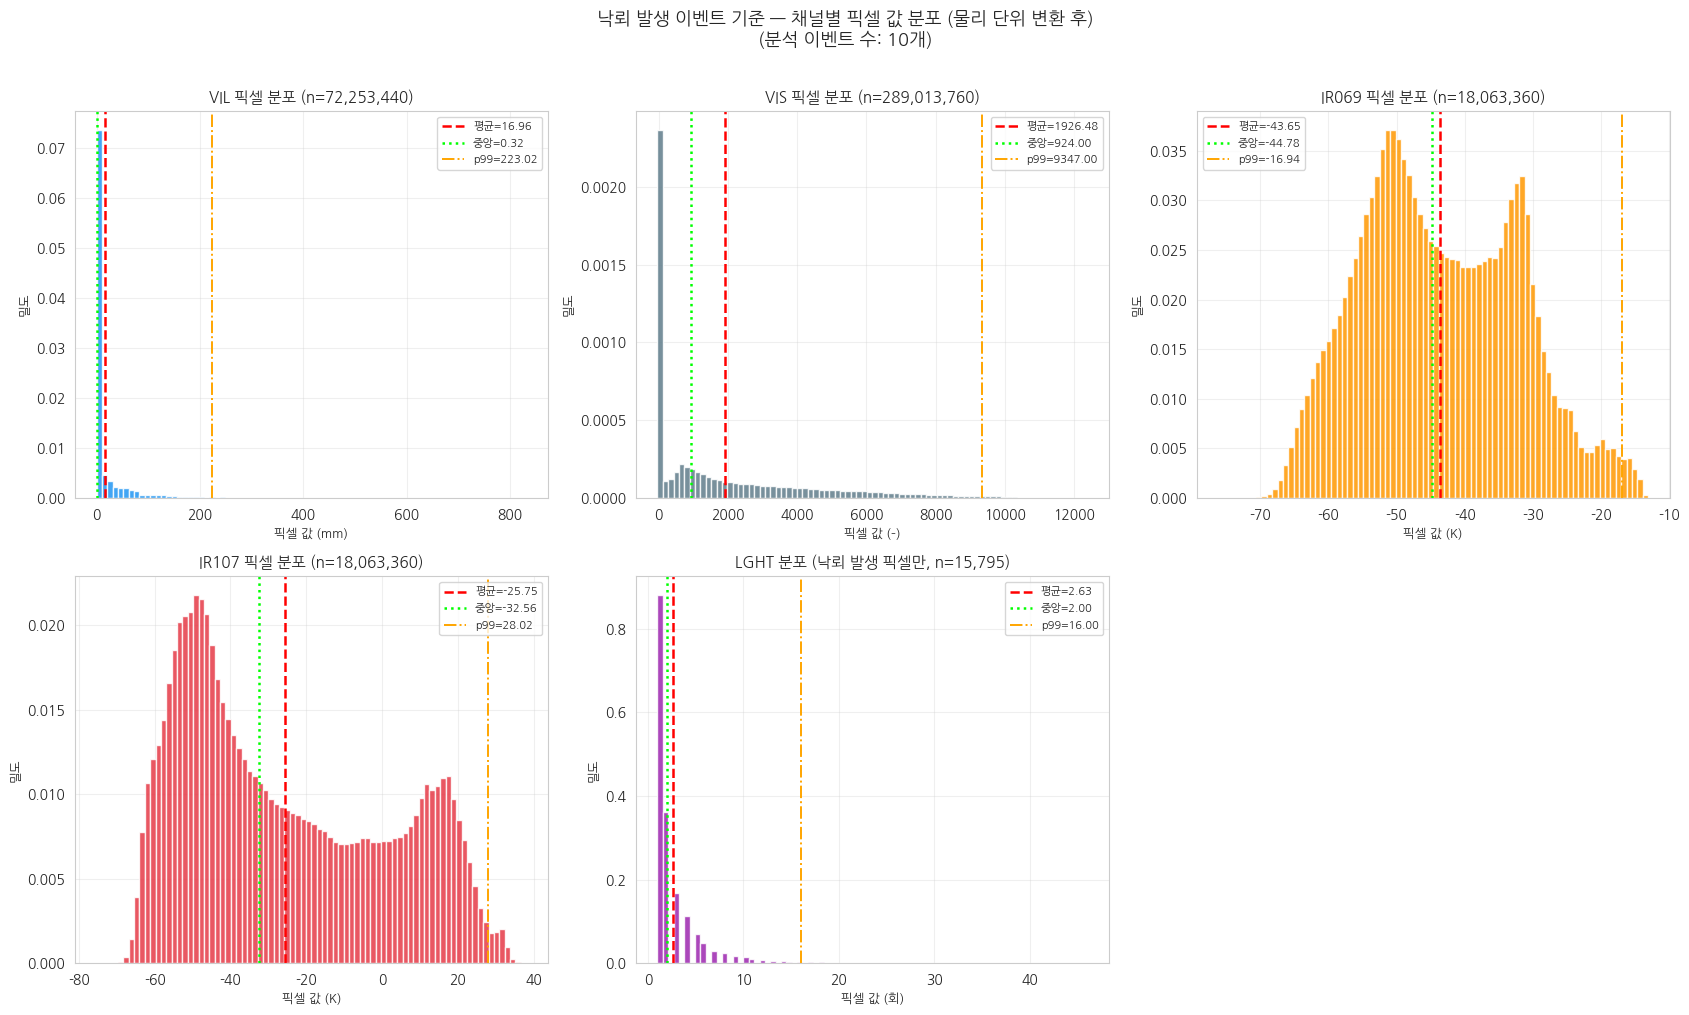

In [18]:
# ── Step 4-D: 채널별 픽셀 값 분포 시각화 ─────────────────────────────
#
# samples = {channel: {event_id: np.ndarray (H, W, 49)}}
# 낙뢰 이벤트 기준으로 로드된 데이터를 물리 단위로 변환해 히스토그램 비교

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.ravel()

palette = {
    'vil'  : '#2196F3',
    'vis'  : '#607D8B',
    'ir069': '#FF9800',
    'ir107': '#E63946',
    'lght' : '#9C27B0',
}

for idx, ch in enumerate(IMG_TYPES.keys()):
    ax = axes[idx]

    # 전 이벤트 픽셀 합산
    all_pix = []
    for arr in samples[ch].values():
        arr_f = arr.astype(np.float32)
        if ch == 'vil':
            arr_f = vil_to_mm(arr.astype(np.uint8))
        elif ch in ('ir069', 'ir107'):
            arr_f = arr_f * 0.01
        all_pix.append(arr_f.ravel())

    flat = np.concatenate(all_pix)

    if ch == 'lght':
        # lght는 0이 압도적 → 낙뢰 픽셀만 표시
        flat = flat[flat > 0]
        title = f'LGHT 분포 (낙뢰 발생 픽셀만, n={len(flat):,})'
    else:
        title = f'{ch.upper()} 픽셀 분포 (n={len(flat):,})'

    ax.hist(flat, bins=80, color=palette[ch],
            edgecolor='white', alpha=0.85, density=True)
    ax.axvline(np.mean(flat),   color='red',   linestyle='--', lw=1.8,
               label=f'평균={np.mean(flat):.2f}')
    ax.axvline(np.median(flat), color='lime',  linestyle=':',  lw=1.8,
               label=f'중앙={np.median(flat):.2f}')
    ax.axvline(np.percentile(flat, 99), color='orange', linestyle='-.', lw=1.4,
               label=f'p99={np.percentile(flat, 99):.2f}')

    ax.set_title(title, fontsize=11)
    ax.set_xlabel(f'픽셀 값 ({IMG_TYPES[ch]["unit"]})', fontsize=9)
    ax.set_ylabel('밀도', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_visible(False)

plt.suptitle(
    '낙뢰 발생 이벤트 기준 — 채널별 픽셀 값 분포 (물리 단위 변환 후)\n'
    f'(분석 이벤트 수: {len(sampled_ids)}개)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

---
## Step 5. 단일 이벤트 전 채널 시각화

동일 이벤트 ID에 대해 5개 채널의 중간 프레임(t=24)을 나란히 시각화합니다.

In [22]:
# ── 분석 샘플 이벤트 목록 확인 ───────────────────────────────────────
SELECTED_EVENT_ID = sampled_ids[0]   # 원하는 인덱스로 변경 가능 (0~9)

sample_row = catalog[catalog['id'] == SELECTED_EVENT_ID]

print(f"분석 샘플 목록 ({len(sampled_ids)}개):")
for i, eid in enumerate(sampled_ids):
    marker = '◀ 선택됨' if eid == SELECTED_EVENT_ID else ''
    print(f"  [{i}] {eid} {marker}")

print(f"\n선택된 이벤트 ID: {SELECTED_EVENT_ID}")
print(sample_row[['id', 'img_type', 'time_utc',
                    'llcrnrlat', 'llcrnrlon', 'urcrnrlat', 'urcrnrlon']].to_string())

분석 샘플 목록 (10개):
  [0] S761995 ◀ 선택됨
  [1] R18052102157788 
  [2] R18050905178315 
  [3] S747477 
  [4] S746737 
  [5] S745883 
  [6] R18052204008222 
  [7] R18052102157408 
  [8] S785989 
  [9] S758848 

선택된 이벤트 ID: S761995
            id img_type            time_utc  llcrnrlat   llcrnrlon  urcrnrlat  urcrnrlon
1434   S761995    ir069 2018-05-23 22:24:00  37.108377 -101.293692  40.603344 -96.910493
16996  S761995      vil 2018-05-23 22:24:00  37.108377 -101.293692  40.603344 -96.910493
43755  S761995    ir107 2018-05-23 22:24:00  37.108377 -101.293692  40.603344 -96.910493
53331  S761995      vis 2018-05-23 22:24:00  37.108377 -101.293692  40.603344 -96.910493
63094  S761995     lght 2018-05-23 22:24:00  37.108377 -101.293692  40.603344 -96.910493


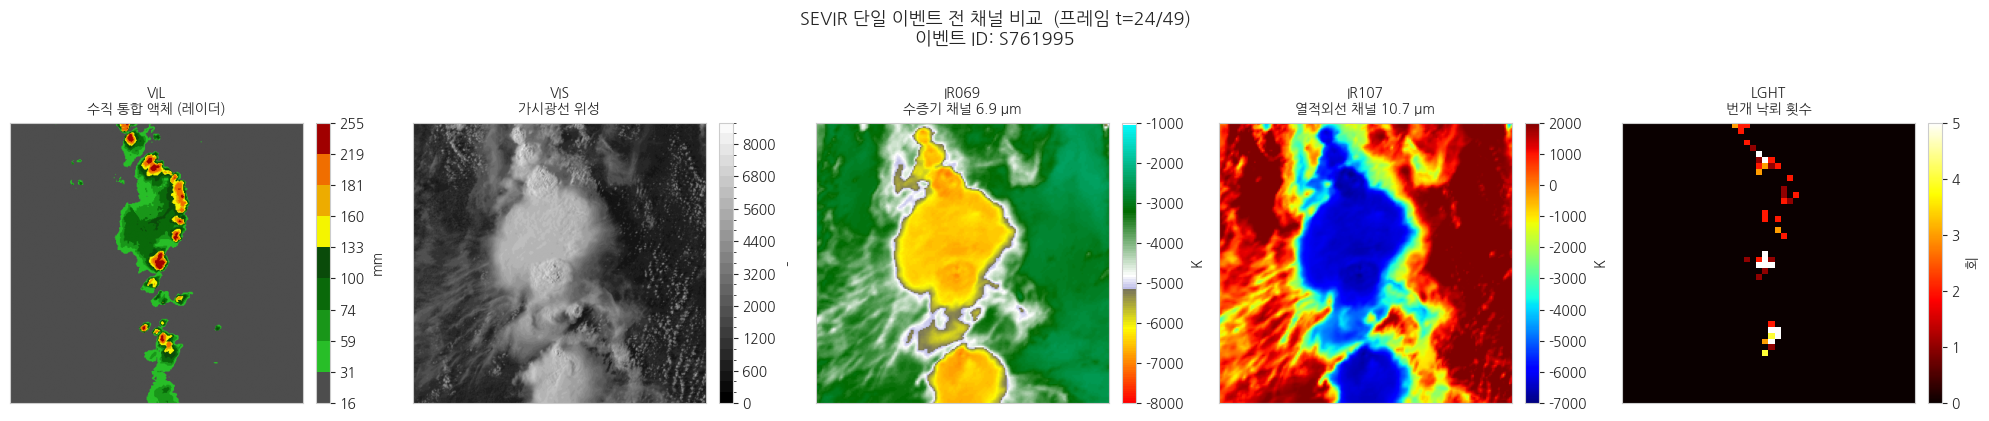

In [26]:
import sys
sys.path.insert(0, '/home/impos/AI4WeatherandClimate')                                                                                                                                                                                                                             
from display import get_cmap

T_MID = 24

vis_cmap,   vis_norm,   vis_vmin,   vis_vmax   = get_cmap('vis',   encoded=True)
ir069_cmap, ir069_norm, ir069_vmin, ir069_vmax = get_cmap('ir069', encoded=True)
ir107_cmap, ir107_norm, ir107_vmin, ir107_vmax = get_cmap('ir107', encoded=True)
vil_cmap,   vil_norm,   vil_vmin,   vil_vmax   = get_cmap('vil',   encoded=True)
lght_cmap,  lght_norm,  lght_vmin,  lght_vmax  = get_cmap('lght',  encoded=True)

CH_DISPLAY = {
    'vil'  : dict(cmap=vil_cmap,   norm=vil_norm,   vmin=vil_vmin,   vmax=vil_vmax),
    'vis'  : dict(cmap=vis_cmap,   norm=vis_norm,   vmin=vis_vmin,   vmax=vis_vmax),
    'ir069': dict(cmap=ir069_cmap, norm=ir069_norm, vmin=ir069_vmin, vmax=ir069_vmax),
    'ir107': dict(cmap=ir107_cmap, norm=ir107_norm, vmin=ir107_vmin, vmax=ir107_vmax),
    'lght' : dict(cmap=lght_cmap,  norm=lght_norm,  vmin=lght_vmin,  vmax=lght_vmax),
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, ch in enumerate(IMG_TYPES.keys()):
    ax = axes[idx]

    if SELECTED_EVENT_ID not in samples[ch]:
        ax.text(0.5, 0.5, '데이터 없음', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(ch.upper())
        continue

    frame = samples[ch][SELECTED_EVENT_ID][:, :, T_MID]

    disp = CH_DISPLAY[ch]
    # norm이 있으면 vmin/vmax를 None으로 (동시에 넘기면 ValueError)
    if disp['norm'] is not None:
        im = ax.imshow(frame, cmap=disp['cmap'], norm=disp['norm'], aspect='auto')
    else:
        im = ax.imshow(frame, cmap=disp['cmap'], vmin=disp['vmin'], vmax=disp['vmax'], aspect='auto')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                label=IMG_TYPES[ch]['unit'])
    ax.set_title(f"{ch.upper()}\n{IMG_TYPES[ch]['description']}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(
    f'SEVIR 단일 이벤트 전 채널 비교  (프레임 t={T_MID}/49)\n'
    f'이벤트 ID: {SELECTED_EVENT_ID}',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()


---
## Step 5-A. 시계열 변화 시각화 — 폭풍 생애 주기 (Temporal Evolution)

폭풍의 **생성 → 발달 → 소멸** 과정을 파악하기 위해  
VIL / IR107 채널에서 일정 간격 5개 프레임을 1행 5열로 나란히 시각화합니다.

| 프레임 | 시간 | 의미 |
|--------|------|------|
| t=0  | 0분   | 이벤트 시작 |
| t=12 | 60분  | 초기 발달 |
| t=24 | 120분 | 중간 (입력/예측 경계) |
| t=36 | 180분 | 후기 발달 |
| t=48 | 240분 | 이벤트 종료 |

시각화 이벤트: [0] S761995


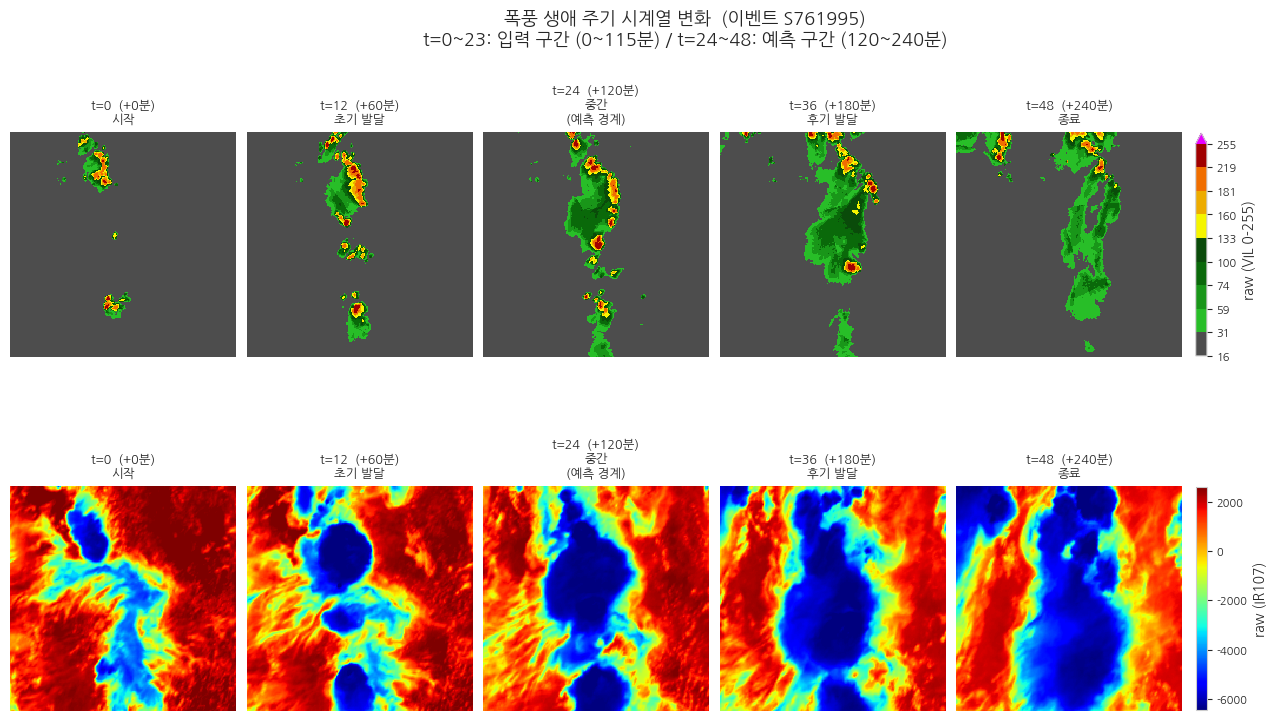

In [35]:
# ── 시계열 변화 시각화 (이미 메모리에 있는 samples 사용, S3 추가 요청 없음) ──
import sys
sys.path.insert(0, '/home/impos/AI4WeatherandClimate')                                                                                                                                                                                                                             
from display import get_cmap
                                                                                                                                                                                                                                                                                    
EVT_IDX  = 0
T_FRAMES = [0, 12, 24, 36, 48]

EVENT_ID = sampled_ids[EVT_IDX]
print(f"시각화 이벤트: [{EVT_IDX}] {EVENT_ID}")

# VIL: raw uint8 그대로 사용 (vil_cmap의 BoundaryNorm이 0-255 기준)
vil_arr = samples['vil'][EVENT_ID].astype(np.float32)
vil_cmap_obj, vil_norm_obj, _, _ = get_cmap('vil', encoded=True)

# IR107: raw 저장값, 실제 범위 기반 vmin/vmax
ir107_arr = samples['ir107'][EVENT_ID].astype(np.float32)
ir107_vmin = float(np.percentile(ir107_arr, 2))
ir107_vmax = float(np.percentile(ir107_arr, 98))
ir107_cmap_obj, _, _, _ = get_cmap('ir107', encoded=True)

CHANNELS = [
    ('vil',   vil_arr,   vil_cmap_obj,   vil_norm_obj, None,       None,       'raw (VIL 0-255)', 'max'),
    ('ir107', ir107_arr, ir107_cmap_obj, None,         ir107_vmin, ir107_vmax, 'raw (IR107)',     'neither'),
]

fig, axes = plt.subplots(
    len(CHANNELS), len(T_FRAMES),
    figsize=(18, 4 * len(CHANNELS)),
    gridspec_kw={'hspace': 0.35, 'wspace': 0.05}
)

for row, (ch, arr, cmap_obj, norm_obj, vmin, vmax, unit, extend) in enumerate(CHANNELS):
    for col, t in enumerate(T_FRAMES):
        ax    = axes[row, col]
        frame = arr[:, :, t]

        if norm_obj is not None:
            im = ax.imshow(frame, cmap=cmap_obj, norm=norm_obj,
                            interpolation='nearest', aspect='equal')
        else:
            im = ax.imshow(frame, cmap=cmap_obj, vmin=vmin, vmax=vmax,
                            interpolation='nearest', aspect='equal')

        phase = ['시작', '초기 발달', '중간\n(예측 경계)', '후기 발달', '종료'][col]
        ax.set_title(f't={t}  (+{t*5}분)\n{phase}', fontsize=9)
        ax.axis('off')

    cbar = fig.colorbar(im, ax=axes[row, :], shrink=0.85, pad=0.01,
                        label=unit, extend=extend)
    cbar.ax.tick_params(labelsize=8)
    axes[row, 0].set_ylabel(ch.upper(), fontsize=12, labelpad=8)

fig.suptitle(
    f'폭풍 생애 주기 시계열 변화  (이벤트 {EVENT_ID})\n'
    't=0~23: 입력 구간 (0~115분) / t=24~48: 예측 구간 (120~240분)',
    fontsize=13, y=1.01
)
plt.show()

In [36]:
# ── VIL 시퀀스 (12개 프레임 선택) ────────────────────────────────────
EVT_IDX  = 2
T_SELECT = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 48]  # 12 프레임
N_ROWS   = 2
N_COLS   = 6

vil_seq  = vil_to_mm(samples['vil'][EVT_IDX])   # (384, 384, 49) mm

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, 7))
axes_flat = axes.ravel()

for plot_i, t in enumerate(T_SELECT):
    ax    = axes_flat[plot_i]
    frame = vil_seq[:, :, t]
    im    = ax.imshow(frame, cmap='Blues', vmin=0, vmax=50, aspect='auto')

    minutes = t * 5
    label   = f't={t}  (+{minutes} min)'
    color   = 'blue' if t < 24 else 'red'
    ax.set_title(label, fontsize=9, color=color, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

    # 입력/출력 구간 테두리
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)

# 컬러바
cbar_ax = fig.add_axes([0.92, 0.1, 0.015, 0.8])
sm      = plt.cm.ScalarMappable(cmap='Blues',
          norm=plt.Normalize(vmin=0, vmax=50))
fig.colorbar(sm, cax=cbar_ax, label='VIL (mm)')

# 범례
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='blue',  alpha=0.3, label='입력 구간 (t=0~23, 0~115분)'),
    Patch(facecolor='red',   alpha=0.3, label='출력 구간 (t=24~48, 120~240분)'),
]
fig.legend(handles=legend_elems, loc='upper center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.02))

plt.suptitle('VIL 4시간 시퀀스 (이벤트 #2)', fontsize=13, y=1.06)
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()
print("파란 테두리 = 입력, 빨간 테두리 = 예측 대상 (Nowcasting 태스크)")

KeyError: 2

시각화 이벤트: [2] R18050905178315


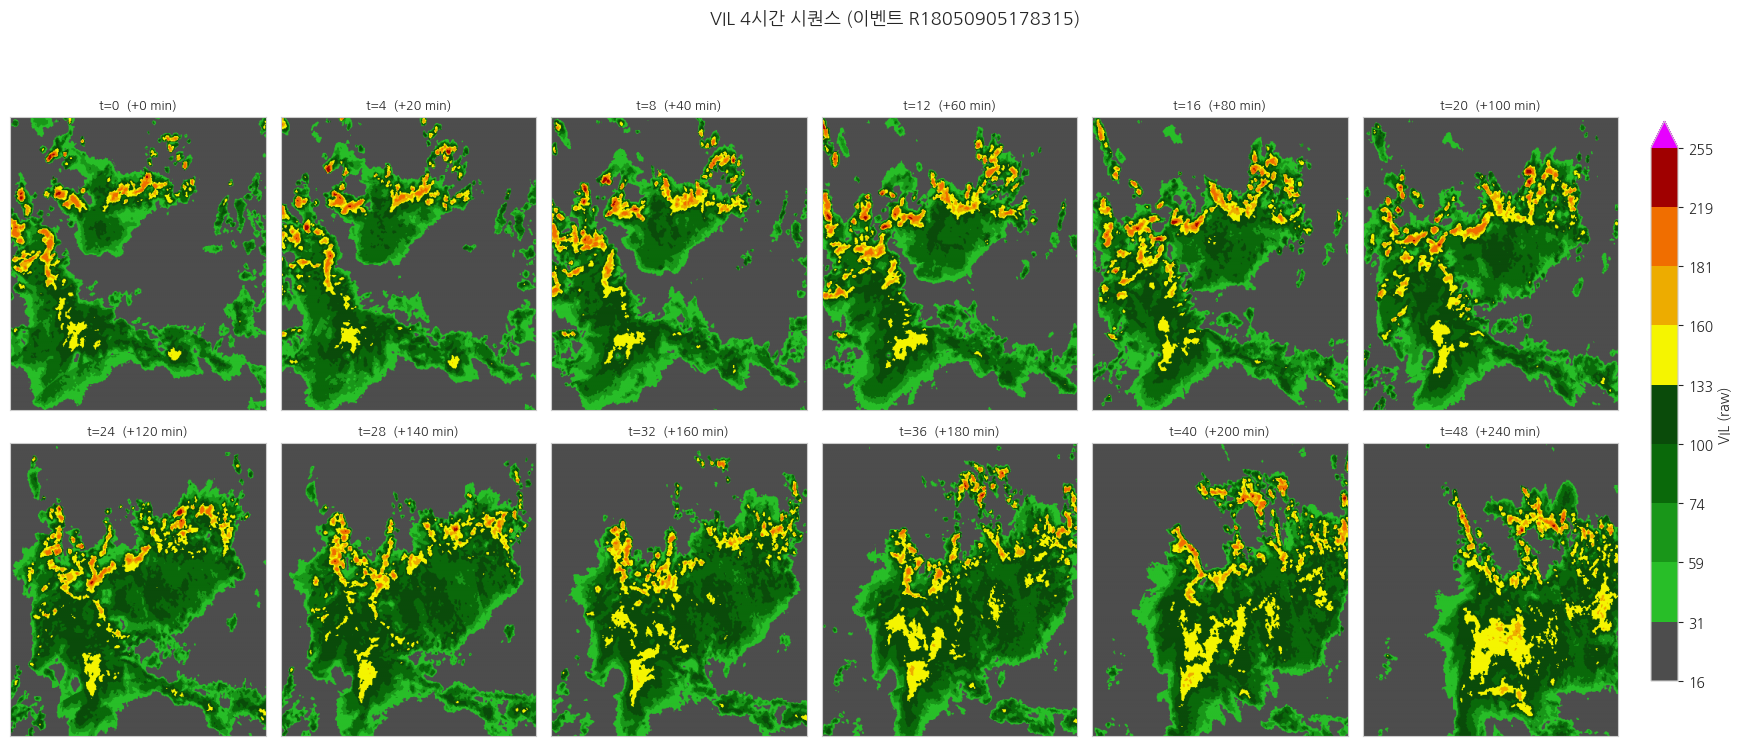

In [37]:
# ── VIL 시퀀스 (12개 프레임 선택) ────────────────────────────────────
import sys
sys.path.insert(0, '/home/impos/AI4WeatherandClimate')                                                                                                                                                                                                                             
from display import get_cmap
                                                                                                                                                                                                                                                                                    
EVT_IDX  = 2
T_SELECT = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 48]
N_ROWS, N_COLS = 2, 6

EVENT_ID = sampled_ids[EVT_IDX]
print(f"시각화 이벤트: [{EVT_IDX}] {EVENT_ID}")

vil_cmap_obj, vil_norm_obj, _, _ = get_cmap('vil', encoded=True)
vil_seq = samples['vil'][EVENT_ID].astype(np.float32)   # (H, W, 49) raw

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, 7))
axes_flat = axes.ravel()

for plot_i, t in enumerate(T_SELECT):
    ax    = axes_flat[plot_i]
    frame = vil_seq[:, :, t]
    im    = ax.imshow(frame, cmap=vil_cmap_obj, norm=vil_norm_obj, aspect='auto')

    minutes = t * 5
    ax.set_title(f't={t}  (+{minutes} min)', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

# 컬러바
cbar_ax = fig.add_axes([0.92, 0.1, 0.015, 0.8])
fig.colorbar(im, cax=cbar_ax, label='VIL (raw)', extend='max')

plt.suptitle(f'VIL 4시간 시퀀스 (이벤트 {EVENT_ID})', fontsize=13, y=1.06)
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()


---
## Step 7. 공간 평균·표준편차 맵 (채널별)

여러 이벤트의 공간적 평균·분산을 계산해 센서별 **관측 패턴**을 확인합니다.

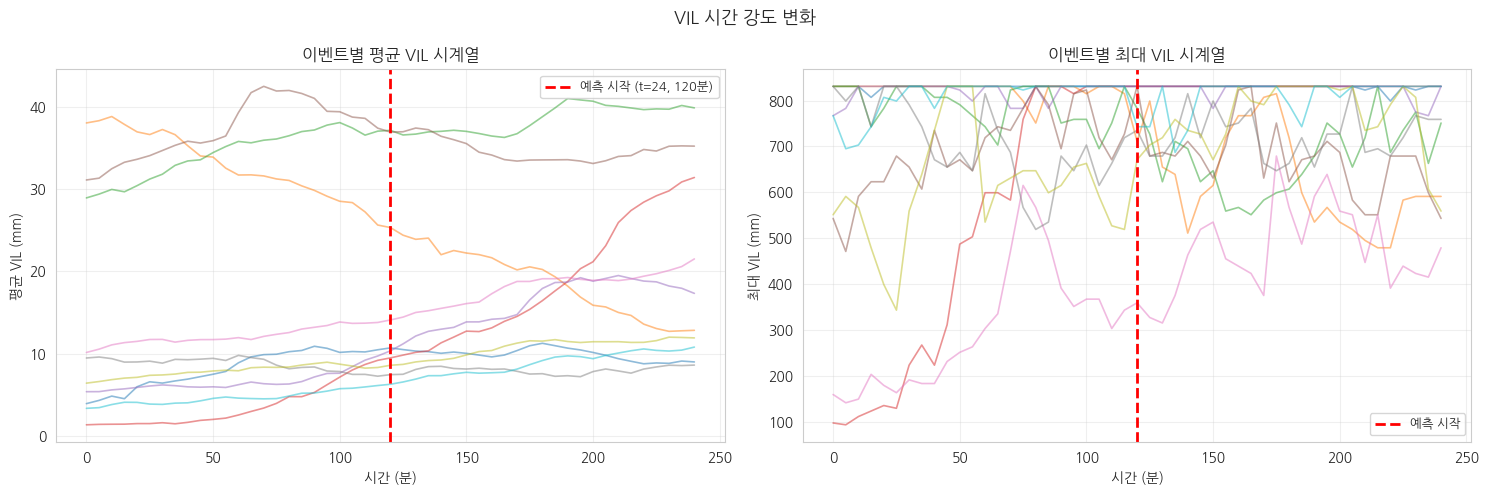

In [39]:
# ── 시간별 VIL 평균 강도 변화 (여러 이벤트) ──────────────────────────
time_ax = np.arange(49) * 5   # 분
                                                                                                                                                                                                                                                                                    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
                                                                                                                                                                                                                                                                                    
for eid in sampled_ids:
    seq = vil_to_mm(samples['vil'][eid].astype(np.uint8))   # (H, W, 49)
    ax1.plot(time_ax, seq.mean(axis=(0, 1)), alpha=0.5, lw=1.2)
    ax2.plot(time_ax, seq.max(axis=(0, 1)),  alpha=0.5, lw=1.2)

ax1.axvline(120, color='red', linestyle='--', lw=2, label='예측 시작 (t=24, 120분)')
ax1.set_xlabel('시간 (분)')
ax1.set_ylabel('평균 VIL (mm)')
ax1.set_title('이벤트별 평균 VIL 시계열', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.axvline(120, color='red', linestyle='--', lw=2, label='예측 시작')
ax2.set_xlabel('시간 (분)')
ax2.set_ylabel('최대 VIL (mm)')
ax2.set_title('이벤트별 최대 VIL 시계열', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('VIL 시간 강도 변화', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 8. 계절 및 시간대별 패턴 분석

카탈로그 메타데이터를 이용해 이벤트의 계절·시간대 분포와 강도 패턴을 분석합니다.

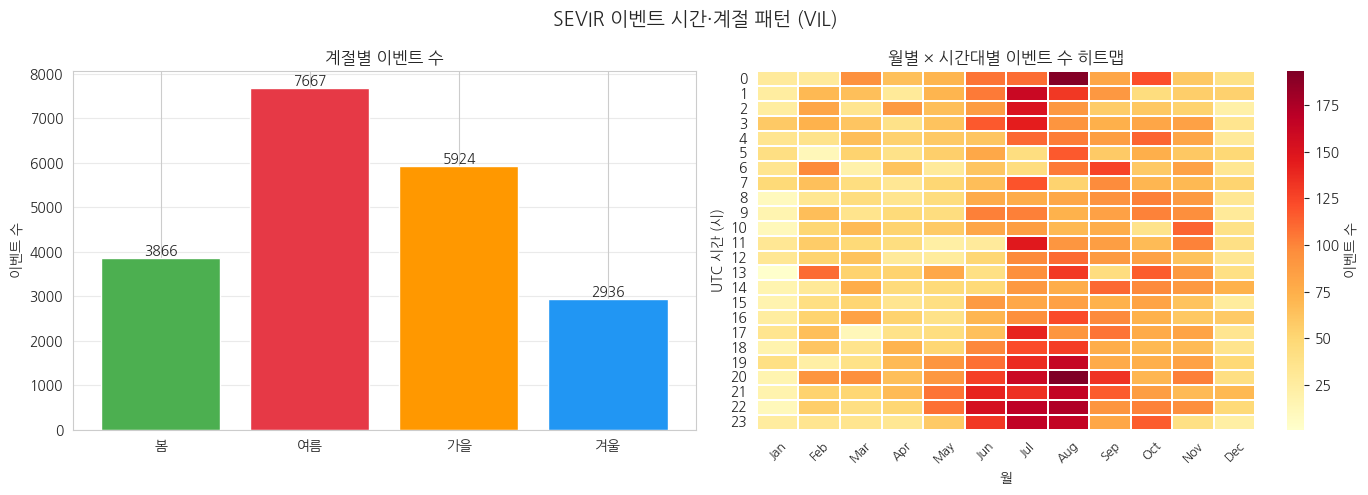

In [40]:
# ── 계절별 이벤트 수 (VIL 기준) ──────────────────────────────────────
season_map = {12:'겨울', 1:'겨울', 2:'겨울',
              3:'봄',   4:'봄',   5:'봄',
              6:'여름', 7:'여름', 8:'여름',
              9:'가을', 10:'가을', 11:'가을'}

cat_vil['season'] = cat_vil['month'].map(season_map)
season_order = ['봄', '여름', '가을', '겨울']
season_colors = {'봄': '#4CAF50', '여름': '#E63946', '가을': '#FF9800', '겨울': '#2196F3'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 계절별 이벤트 수
season_counts = cat_vil['season'].value_counts().reindex(season_order)
axes[0].bar(season_counts.index,
            season_counts.values,
            color=[season_colors[s] for s in season_counts.index],
            edgecolor='white')
axes[0].set_title('계절별 이벤트 수', fontsize=12)
axes[0].set_ylabel('이벤트 수')
axes[0].bar_label(axes[0].containers[0], fontsize=10)
axes[0].grid(axis='y', alpha=0.4)

# 월별 × 시간대별 히트맵
pivot = cat_vil.pivot_table(index='hour', columns='month', aggfunc='size', fill_value=0)
sns.heatmap(
    pivot, ax=axes[1],
    cmap='YlOrRd', linewidths=0.3,
    cbar_kws={'label': '이벤트 수'}
)
axes[1].set_title('월별 × 시간대별 이벤트 수 히트맵', fontsize=12)
axes[1].set_xlabel('월')
axes[1].set_ylabel('UTC 시간 (시)')
axes[1].set_xticklabels(month_names, rotation=45, fontsize=9)

plt.suptitle('SEVIR 이벤트 시간·계절 패턴 (VIL)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 9. 채널 간 상관 분석

동일 이벤트에서 여러 채널의 픽셀 값 (공간 평균) 상관관계를 분석합니다.

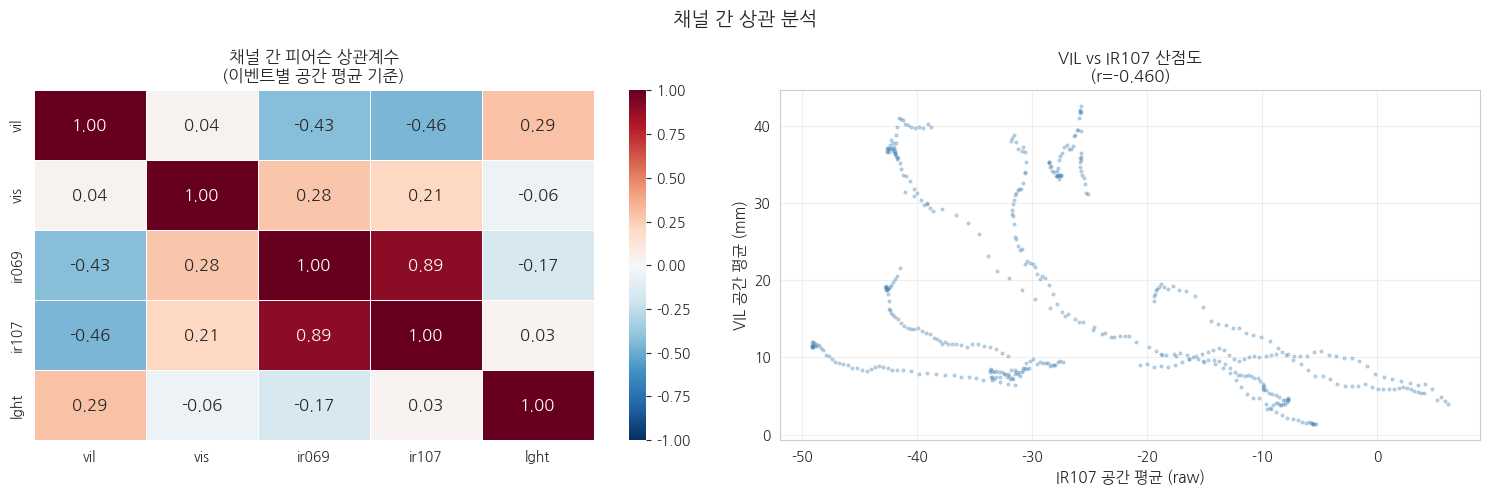

In [42]:
# ── 이벤트별 × 시간별 공간 평균 피처 생성 ────────────────────────────
records = []
for eid in sampled_ids:                                                                                                                                                                                                                                                            
    for t in range(49):
        row = {}                                                                                                                                                                                                                                                                   
        for ch in IMG_TYPES.keys():
            frame = samples[ch][eid][:, :, t].astype(np.float32)
            if ch in ('ir069', 'ir107'):
                frame = frame * 0.01
            elif ch == 'vil':
                frame = vil_to_mm(samples[ch][eid][:, :, t].astype(np.uint8))
            row[ch] = float(frame.mean())
        records.append(row)

feat_df  = pd.DataFrame(records)
corr_mat = feat_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat, ax=axes[0],
    annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 12}
)
axes[0].set_title('채널 간 피어슨 상관계수\n(이벤트별 공간 평균 기준)', fontsize=12)

axes[1].scatter(
    feat_df['ir107'], feat_df['vil'],
    s=4, alpha=0.3, color='steelblue'
)
axes[1].set_xlabel('IR107 공간 평균 (raw)', fontsize=11)
axes[1].set_ylabel('VIL 공간 평균 (mm)', fontsize=11)
axes[1].set_title(f"VIL vs IR107 산점도\n(r={corr_mat.loc['vil','ir107']:.3f})", fontsize=12)
axes[1].grid(alpha=0.3)

plt.suptitle('채널 간 상관 분석', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 10. 데이터 품질 점검 및 DL 학습 노트

### 결측 이벤트 확인
카탈로그에서 특정 채널 데이터가 누락된 이벤트를 확인합니다.

In [43]:
# ── 이벤트 ID별 채널 커버리지 점검 ──────────────────────────────────
event_channels = catalog.groupby('id')['img_type'].apply(set)
all_channels   = set(IMG_TYPES.keys())

complete       = event_channels[event_channels.apply(lambda x: x == all_channels)]
incomplete     = event_channels[event_channels.apply(lambda x: x != all_channels)]

print(f"전체 이벤트 ID 수     : {len(event_channels):>7,}")
print(f"5개 채널 완전 이벤트  : {len(complete):>7,}  ({len(complete)/len(event_channels)*100:.1f}%)")
print(f"채널 누락 이벤트      : {len(incomplete):>7,}  ({len(incomplete)/len(event_channels)*100:.1f}%)")

if len(incomplete) > 0:
    missing_patterns = incomplete.value_counts()
    print("\n누락 패턴:")
    for pat, cnt in missing_patterns.head(10).items():
        missing = all_channels - set(pat)
        print(f"  누락={missing}  →  {cnt}개 이벤트")

전체 이벤트 ID 수     :  20,838
5개 채널 완전 이벤트  :  12,707  (61.0%)
채널 누락 이벤트      :   8,131  (39.0%)

누락 패턴:
  누락={'ir107', 'lght', 'ir069', 'vis'}  →  5690개 이벤트
  누락={'ir107', 'ir069', 'vis'}  →  1622개 이벤트
  누락={'vil'}  →  556개 이벤트
  누락={'vis'}  →  156개 이벤트
  누락={'ir107', 'ir069'}  →  36개 이벤트
  누락={'lght'}  →  32개 이벤트
  누락={'ir107', 'vis'}  →  19개 이벤트
  누락={'ir069', 'vis'}  →  9개 이벤트
  누락={'vil', 'vis'}  →  8개 이벤트
  누락={'lght', 'vis'}  →  1개 이벤트


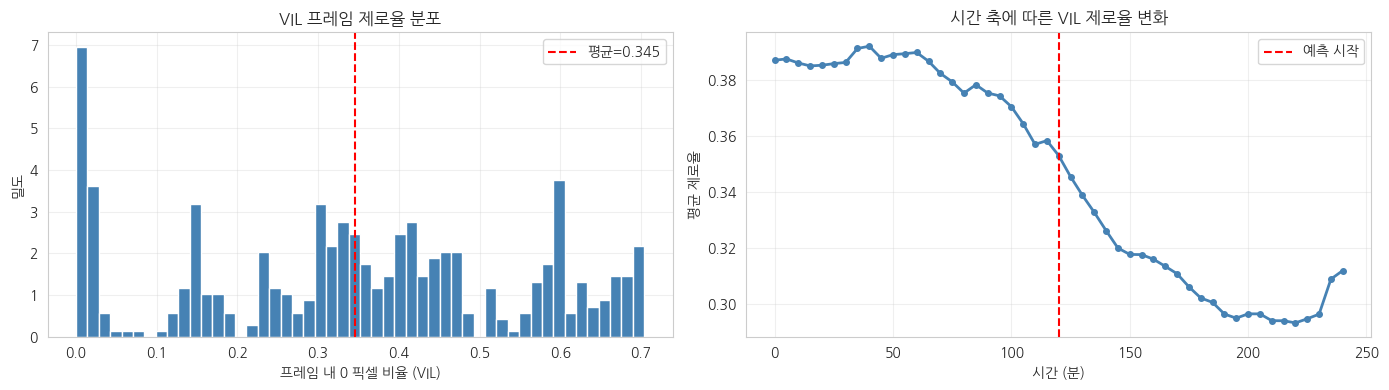

In [45]:
# ── VIL 제로(무강수) 프레임 비율 확인 ────────────────────────────────
zero_frame_rates = []
                                                                                                                                                                                                                                                                                    
for eid in sampled_ids:
    seq = samples['vil'][eid]    # (H, W, 49)                                                                                                                                                                                                                                      
    for t in range(49):
        frame = seq[:, :, t]
        zero_rate = (frame == 0).mean()
        zero_frame_rates.append({'event': eid, 't': t, 'zero_rate': zero_rate})

zfr_df = pd.DataFrame(zero_frame_rates)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(zfr_df['zero_rate'], bins=50, color='steelblue',
            edgecolor='white', density=True)
axes[0].axvline(zfr_df['zero_rate'].mean(), color='red', linestyle='--', lw=1.5,
                label=f"평균={zfr_df['zero_rate'].mean():.3f}")
axes[0].set_xlabel('프레임 내 0 픽셀 비율 (VIL)')
axes[0].set_ylabel('밀도')
axes[0].set_title('VIL 프레임 제로율 분포')
axes[0].legend()
axes[0].grid(alpha=0.3)

mean_by_t = zfr_df.groupby('t')['zero_rate'].mean()
axes[1].plot(mean_by_t.index * 5, mean_by_t.values, 'o-',
            color='steelblue', lw=2, ms=4)
axes[1].axvline(120, color='red', linestyle='--', lw=1.5, label='예측 시작')
axes[1].set_xlabel('시간 (분)')
axes[1].set_ylabel('평균 제로율')
axes[1].set_title('시간 축에 따른 VIL 제로율 변화')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
# ── DL 학습용 정규화 통계 (채널별 평균·표준편차) ──────────────────────
print("=" * 60)
print("DL 학습 데이터 전처리 정규화 참고값 (샘플 기준)")
print("=" * 60)
print(f"{'채널':<8} {'평균':>10} {'표준편차':>10} {'최솟값':>10} {'99%ile':>10} {'단위':>6}")
print("-" * 60)

for ch in IMG_TYPES.keys():
    s = stats[ch]
    print(f"{ch:<8} {s['mean']:>10.3f} {s['std']:>10.3f} "
          f"{s['min']:>10.3f} {s['p99']:>10.3f} {s['unit']:>6}")

print()
print("DL 학습 시 주의사항:")
notes = [
    "VIL : uint8(0~255) → LUT 변환(0~70mm) 또는 /255 단순 정규화 모두 사용됨",
    "VIS : uint8(0~255) → /255 정규화 권장",
    "IR069/IR107 : int16 (×0.01 K) → Z-score 정규화 권장 (음수 포함)",
    "LGHT : 대부분 0, 희소 이벤트 → log1p 변환 후 정규화 권장",
    "클래스 불균형: VIL=0(무강수) 비율이 매우 높음 → 가중 손실 함수 또는 thresholding 필요",
    "공간 패딩 : 384×384 → 2의 거듭제곱(256,512)으로 crop/pad 고려",
    "배치 구성 : 이벤트 단위 (N, T, C, H, W) 또는 (N, C, T, H, W) 형태 사용",
]
for note in notes:
    print(f"  - {note}")

DL 학습 데이터 전처리 정규화 참고값 (샘플 기준)
채널               평균       표준편차        최솟값     99%ile     단위
------------------------------------------------------------
vil          16.957     47.602      0.000    223.020     mm
vis        1926.480   2399.090    -35.000   9347.000      –
ir069       -43.653     11.430    -76.140    -16.940      K
ir107       -25.747     26.794    -75.350     28.020      K
lght          0.037      0.473      0.000      1.000      회

DL 학습 시 주의사항:
  - VIL : uint8(0~255) → LUT 변환(0~70mm) 또는 /255 단순 정규화 모두 사용됨
  - VIS : uint8(0~255) → /255 정규화 권장
  - IR069/IR107 : int16 (×0.01 K) → Z-score 정규화 권장 (음수 포함)
  - LGHT : 대부분 0, 희소 이벤트 → log1p 변환 후 정규화 권장
  - 클래스 불균형: VIL=0(무강수) 비율이 매우 높음 → 가중 손실 함수 또는 thresholding 필요
  - 공간 패딩 : 384×384 → 2의 거듭제곱(256,512)으로 crop/pad 고려
  - 배치 구성 : 이벤트 단위 (N, T, C, H, W) 또는 (N, C, T, H, W) 형태 사용


---
## EDA 요약

### 데이터셋 핵심 특성

| 항목 | 내용 |
|------|------|
| 이벤트 해상도 | 384×384 픽셀 (VIL/VIS/IR) · 48×48 (LGHT) |
| 시퀀스 길이 | 49 프레임 × 5분 = 4시간 |
| 태스크 구분 | 입력 t=0~23 (0~115분) → 예측 t=24~48 (120~240분) |
| 주요 과제 | VIL 클래스 불균형 (0 픽셀 > 70%), IR 채널 음수 값 포함 |
| 활용 채널 | 단일(VIL) 또는 5개 멀티채널 모두 가능 |

### 권장 전처리 요약

```python
# VIL
vil_norm = vil_raw.astype(np.float32) / 255.0   # 단순 정규화
# 또는 VIL_LUT[vil_raw] / 70.0                  # 물리 단위 정규화

# IR069 / IR107
ir_kelvin = ir_raw.astype(np.float32) * 0.01    # K 변환
ir_norm   = (ir_kelvin - MEAN_K) / STD_K        # Z-score

# LGHT
lght_norm = np.log1p(lght_raw.astype(np.float32))  # log 변환
```

### 참고 벤치마크

- **EarthFormer** (NeurIPS 2022) — VIL Nowcasting
- **PreDiff** (NeurIPS 2023) — 확률적 강수 예측
- **NowcastNet** — 비선형 시계열 예측
- 공식 평가 지표: **CSI (Critical Success Index)** at 16, 74, 133, 160, 181, 219 mm/hr 임계값